# 02 — Relações entre as variáveis e a classificação do acidente

Este notebook aprofunda a análise exploratória iniciada no notebook 01. O objetivo é investigar como as variáveis se relacionam entre si e com `classificacao_acidente`, distinguindo **frequência de acidentes** de **proporção de gravidade**.

A análise é associativa, não causal. Colunas que determinam diretamente o alvo (`mortos`, `feridos` e derivadas) não são usadas para avaliar poder preditivo, pois constituem vazamento do alvo.

### Perguntas que queremos responder

1. Qual é a proporção de cada classificação de acidente?
2. Em quais categorias a distribuição das classes muda mais?
3. As variáveis numéricas mudam entre as classes?
4. Combinações como pista simples e noite revelam padrões adicionais?
5. Quais variáveis trazem informações parecidas entre si?

## 1. Preparação do ambiente

Execute as células na ordem, de cima para baixo. Cada célula de código depende das anteriores. `pandas` organiza os dados em tabelas, `numpy` auxilia nos cálculos, `matplotlib` e `seaborn` criam os gráficos e `scipy` fornece os testes estatísticos. As cores das três classes são fixadas para manter a leitura consistente.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal

# Fix para executar o notebook tanto na raiz do projeto quanto na pasta notebooks.
RAIZ_PROJETO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ_PROJETO / "src"))

from prf_accidents_feature_importance.features.build_features import (
    ARQUIVO_ENTRADA,
    COLUNA_ALVO,
    construir_features,
)

PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)
ORDEM_ALVO = ["sem vitimas", "com vitimas feridas", "com vitimas fatais"]
PALETA_ALVO = dict(zip(ORDEM_ALVO, sns.color_palette("colorblind", 3)))
sns.set_theme(style="whitegrid", palette="colorblind")

## 2. Leitura e enriquecimento analítico

Cada linha representa um acidente. A coluna `classificacao_acidente`, chamada de **alvo** ou **target**, é a informação que um futuro modelo tentará prever.

Reaproveitamos as mesmas transformações do pipeline para analisar exatamente as features usadas na modelagem. Criamos ainda `ano`, `mes`, `hora`, `fim_de_semana` e `classe_fatal` somente na memória. O valor 1 em `classe_fatal` significa acidente fatal e 0 significa outra classificação. O arquivo original não é alterado.

In [2]:
acidentes = pd.read_parquet(ARQUIVO_ENTRADA)
dados = construir_features(acidentes)
originais_validos = acidentes.dropna(subset=[COLUNA_ALVO]).reset_index(drop=True)

# Variáveis úteis à análise, sem modificar o contrato de features do projeto.
dados["ano"] = originais_validos["data_inversa"].dt.year.astype("Int64")
dados["mes"] = originais_validos["data_inversa"].dt.month.astype("Int64")
dados["hora"] = pd.to_numeric(
    originais_validos["horario"].astype("string").str[:2], errors="coerce"
).astype("Int64")
dados["fim_de_semana"] = dados["dia_semana"].isin(["sabado", "domingo"])
dados["classe_fatal"] = dados[COLUNA_ALVO].eq("com vitimas fatais").astype("int8")
dados[COLUNA_ALVO] = pd.Categorical(
    dados[COLUNA_ALVO], categories=ORDEM_ALVO, ordered=True
)

print(f"Linhas analisadas: {len(dados):,}")
print(f"Período: {originais_validos['data_inversa'].min():%d/%m/%Y} a {originais_validos['data_inversa'].max():%d/%m/%Y}")
display(dados.head())

Linhas analisadas: 187,348
Período: 02/11/2023 a 31/05/2026


,dia_semana,br,fase_dia,condicao_meteorologica,tipo_pista,inclinacao,reta,km,volume_pedagio,icm,fator_humano,classificacao_acidente,ano,mes,hora,fim_de_semana,classe_fatal
0,quinta-feira,116,plena noite,chuva,dupla,nivelado,reta,59.9,1419025.0,<NA>,1,com vitimas fatais,2023,12,0,False,1
1,quinta-feira,259,amanhecer,nublado,simples,nivelado,reta,12.8,<NA>,19.5,0,sem vitimas,2023,12,4,False,0
2,quinta-feira,116,plena noite,ceu claro,simples,declive,curva,544.0,755787.0,<NA>,1,com vitimas feridas,2023,12,0,False,0
3,quinta-feira,392,amanhecer,ceu claro,simples,nivelado,reta,102.4,119287.0,22.5,1,com vitimas feridas,2023,12,6,False,0
4,quinta-feira,232,pleno dia,ceu claro,dupla,nivelado,reta,41.0,<NA>,<NA>,1,com vitimas feridas,2023,12,6,False,0


## 3. Funções auxiliares

Para não repetir código, criamos três funções auxiliares:

- `perfil_por_categoria` conta os acidentes e calcula os percentuais dentro de cada categoria;
- `cramers_v_corrigido` mede a força da relação entre uma coluna categórica e o alvo;
- `associacao_numerica` compara uma variável numérica entre as três classes.

Também calculamos um intervalo de confiança de 95% para a taxa fatal. Ele é uma faixa plausível para a taxa real: grupos menores produzem faixas mais largas e, portanto, mais incerteza.

In [3]:
def perfil_por_categoria(df, coluna, minimo=1, max_categorias=None):
    """Resume contagens e percentuais do alvo para cada valor de uma coluna."""
    # Mantemos apenas a variável estudada e o alvo.
    base = df[[coluna, COLUNA_ALVO]].copy()
    base[coluna] = base[coluna].astype("string").fillna("ausente")
    # Categorias raras são removidas conforme o limite informado em `minimo`.
    frequencias = base[coluna].value_counts()
    categorias = frequencias[frequencias >= minimo].index
    if max_categorias is not None:
        categorias = categorias[:max_categorias]
    base = base[base[coluna].isin(categorias)]
    # A tabela cruzada conta quantas linhas pertencem a cada combinação.
    tabela = pd.crosstab(base[coluna], base[COLUNA_ALVO]).reindex(columns=ORDEM_ALVO, fill_value=0)
    totais = tabela.sum(axis=1)
    # Dividir cada linha pelo seu total transforma contagens em percentuais.
    percentuais = tabela.div(totais, axis=0).mul(100)
    fatais = tabela["com vitimas fatais"]
    # z=1,96 corresponde ao intervalo de confiança de 95% de Wilson.
    z = 1.96
    proporcao = fatais / totais
    centro = (proporcao + z**2 / (2 * totais)) / (1 + z**2 / totais)
    margem = z * np.sqrt((proporcao * (1 - proporcao) + z**2 / (4 * totais)) / totais) / (1 + z**2 / totais)
    resumo = percentuais.rename(columns=lambda c: f"pct_{c}")
    resumo.insert(0, "n", totais)
    resumo["fatal_ic95_inf"] = (centro - margem).mul(100)
    resumo["fatal_ic95_sup"] = (centro + margem).mul(100)
    return resumo.sort_values("pct_com vitimas fatais", ascending=False)


def cramers_v_corrigido(df, coluna):
    """Calcula a força da associação categórica com o alvo."""
    x = df[coluna].astype("string").fillna("ausente")
    tabela = pd.crosstab(x, df[COLUNA_ALVO])
    qui2, p_valor, _, _ = chi2_contingency(tabela)
    n = tabela.to_numpy().sum()
    linhas, colunas = tabela.shape
    phi2 = qui2 / n
    phi2_corrigido = max(0, phi2 - ((colunas - 1) * (linhas - 1)) / (n - 1))
    linhas_corrigidas = linhas - ((linhas - 1) ** 2) / (n - 1)
    colunas_corrigidas = colunas - ((colunas - 1) ** 2) / (n - 1)
    denominador = min(colunas_corrigidas - 1, linhas_corrigidas - 1)
    v = np.sqrt(phi2_corrigido / denominador) if denominador > 0 else np.nan
    return v, p_valor


def associacao_numerica(df, coluna):
    """Compara a distribuição numérica entre as classes do alvo."""
    # Criamos uma amostra separada para cada classificação de acidente.
    amostras = [
        df.loc[df[COLUNA_ALVO].eq(classe), coluna].dropna().astype(float)
        for classe in ORDEM_ALVO
    ]
    h, p_valor = kruskal(*amostras)
    n = sum(map(len, amostras))
    epsilon2 = max(0, (h - len(amostras) + 1) / (n - len(amostras)))
    return epsilon2, p_valor, n

## 4. Panorama do alvo

A **prevalência** é a porcentagem de cada classe no conjunto. Ela funciona como referência para as próximas comparações.

É importante distinguir duas perguntas:

- **Onde há mais acidentes?** Use a quantidade absoluta.
- **Onde os acidentes registrados são proporcionalmente mais graves?** Use o percentual dentro do grupo.

Uma categoria muito comum pode ter muitos acidentes fatais apenas por conter muitos acidentes no total. Por isso, uma categoria só sugere gravidade relativamente maior quando sua proporção fatal supera a média global.

,quantidade,percentual
classificacao_acidente,,
sem vitimas,29365,15.67
com vitimas feridas,144660,77.21
com vitimas fatais,13323,7.11


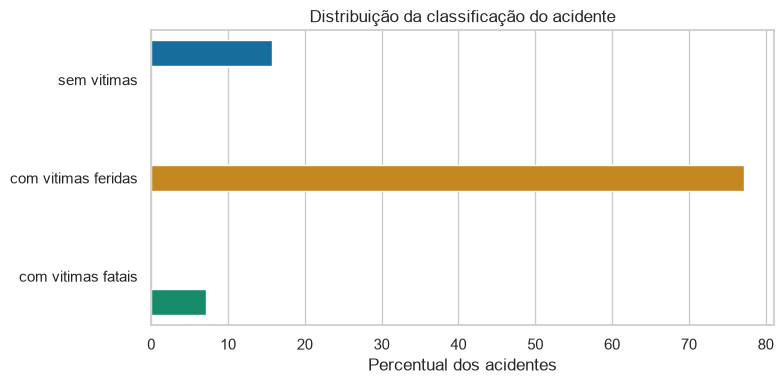

In [4]:
distribuicao_alvo = (
    dados[COLUNA_ALVO].value_counts(sort=False)
    .rename("quantidade")
    .to_frame()
)
distribuicao_alvo["percentual"] = distribuicao_alvo["quantidade"].div(len(dados)).mul(100)
display(distribuicao_alvo.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=distribuicao_alvo.reset_index(), x="percentual", y=COLUNA_ALVO, hue=COLUNA_ALVO, palette=PALETA_ALVO, legend=False, ax=ax)
ax.set(title="Distribuição da classificação do acidente", xlabel="Percentual dos acidentes", ylabel="")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "eda2_distribuicao_alvo.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Associação das variáveis categóricas com o alvo

Uma variável **categórica** representa grupos, como `tipo_pista` = simples, dupla ou múltipla. Para medir quanto a distribuição do alvo muda entre esses grupos, usamos o V de Cramér corrigido.

O V varia de 0 a 1: próximo de 0 indica pouca associação; quanto maior, mais a composição das classes muda entre as categorias. Esses valores devem ser comparados entre as variáveis deste conjunto, e não tratados como limites universais.

O valor-p testa se a diferença observada é compatível com acaso, mas não mede importância. Como há mais de 187 mil linhas, até diferenças muito pequenas podem produzir valor-p próximo de zero. Por isso, o ranking é ordenado pelo V de Cramér, que mede o **tamanho da associação**.

,variavel,cramers_v,p_valor,categorias
1,br,0.1138,0.000000,118
11,hora,0.1123,0.000000,24
7,fator_humano,0.1109,0.000000,2
2,fase_dia,0.0901,0.000000,4
4,tipo_pista,0.0727,0.000000,3
8,fim_de_semana,0.0660,0.000000,2
0,dia_semana,0.0481,0.000000,7
5,inclinacao,0.0321,0.000000,3
3,condicao_meteorologica,0.0294,0.000000,10
6,reta,0.0204,0.000000,2


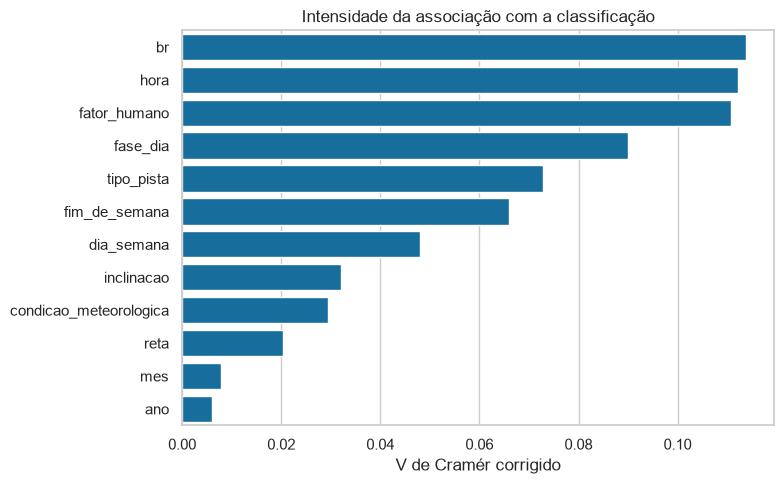

In [5]:
categoricas = [
    "dia_semana", "br", "fase_dia", "condicao_meteorologica",
    "tipo_pista", "inclinacao", "reta", "fator_humano",
    "fim_de_semana", "ano", "mes", "hora",
]
linhas = []
for coluna in categoricas:
    v, p_valor = cramers_v_corrigido(dados, coluna)
    linhas.append({"variavel": coluna, "cramers_v": v, "p_valor": p_valor, "categorias": dados[coluna].nunique(dropna=False)})

ranking_categoricas = pd.DataFrame(linhas).sort_values("cramers_v", ascending=False)
display(ranking_categoricas.round({"cramers_v": 4, "p_valor": 6}))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=ranking_categoricas, x="cramers_v", y="variavel", ax=ax, color=sns.color_palette()[0])
ax.set(title="Intensidade da associação com a classificação", xlabel="V de Cramér corrigido", ylabel="")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "eda2_cramers_v.png", dpi=160, bbox_inches="tight")
plt.show()

### 5.1 Perfis das principais variáveis categóricas

Os mapas de calor normalizam cada linha para 100%. Leia uma linha de cada vez: as três células daquela linha somam 100% e mostram como os acidentes da categoria se dividem entre as classificações.

Azul mais escuro significa percentual maior. Isso permite comparar a composição da gravidade, mas não informa qual categoria teve mais acidentes — para isso, consulte a coluna `n` nas tabelas da seção seguinte.

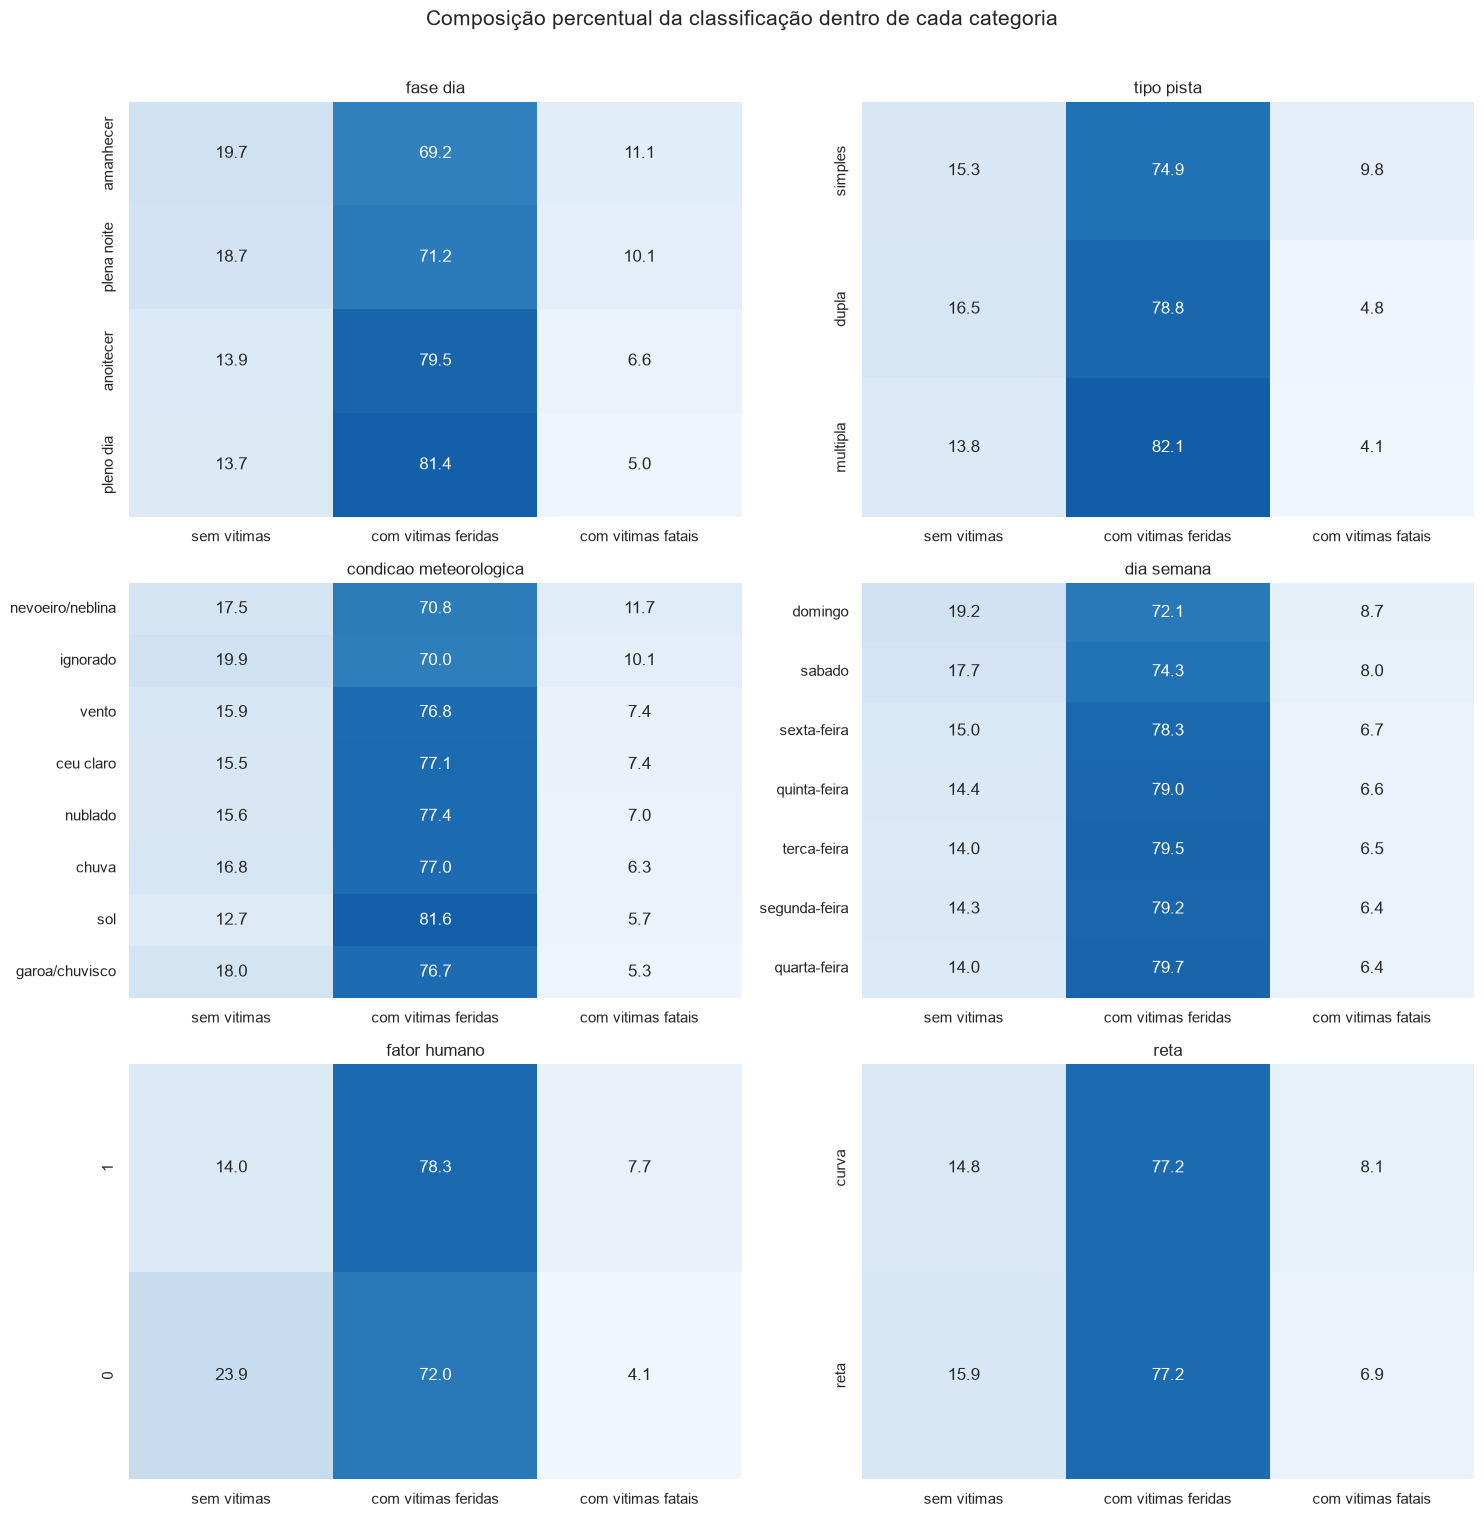

In [6]:
variaveis_perfil = ["fase_dia", "tipo_pista", "condicao_meteorologica", "dia_semana", "fator_humano", "reta"]
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
for coluna, ax in zip(variaveis_perfil, axes.flat):
    perfil = perfil_por_categoria(dados, coluna, minimo=100)
    percentuais = perfil[[f"pct_{classe}" for classe in ORDEM_ALVO]]
    percentuais.columns = ORDEM_ALVO
    sns.heatmap(percentuais, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100, cbar=False, ax=ax)
    ax.set(title=coluna.replace("_", " "), xlabel="", ylabel="")
fig.suptitle("Composição percentual da classificação dentro de cada categoria", y=1.01, fontsize=15)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "eda2_perfis_categoricos.png", dpi=160, bbox_inches="tight")
plt.show()

### 5.2 Categorias com maior proporção fatal

A tabela mostra `n` (total de acidentes), os três percentuais e os limites inferior e superior do intervalo de confiança da taxa fatal.

Exigimos um número mínimo de acidentes antes de colocar uma categoria no ranking. Sem esse filtro, uma categoria com apenas dois acidentes, sendo um fatal, apareceria com 50% e poderia parecer importante sem evidência suficiente. Se os intervalos de duas categorias se sobrepõem bastante, a ordem entre elas deve ser vista com cautela.

In [7]:
for coluna, minimo in {"br": 500, "fase_dia": 100, "condicao_meteorologica": 200, "tipo_pista": 100}.items():
    print(f"\n{coluna.upper()}")
    display(perfil_por_categoria(dados, coluna, minimo=minimo).head(12).round(2))


BR


classificacao_acidente,n,pct_sem vitimas,pct_com vitimas feridas,pct_com vitimas fatais,fatal_ic95_inf,fatal_ic95_sup
br,,,,,,
423,529,15.88,65.60,18.53,15.45,22.06
242,834,16.19,66.67,17.15,14.74,19.85
226,768,12.63,70.57,16.80,14.32,19.60
10,1289,16.21,67.73,16.06,14.16,18.16
222,1478,15.83,68.47,15.70,13.93,17.64
135,1430,19.93,64.76,15.31,13.54,17.27
316,3250,16.03,69.02,14.95,13.77,16.22
407,775,14.19,72.13,13.68,11.44,16.28
110,867,11.65,74.74,13.61,11.49,16.05



FASE_DIA


classificacao_acidente,n,pct_sem vitimas,pct_com vitimas feridas,pct_com vitimas fatais,fatal_ic95_inf,fatal_ic95_sup
fase_dia,,,,,,
amanhecer,8876,19.66,69.22,11.12,10.48,11.79
plena noite,64145,18.66,71.22,10.11,9.88,10.35
anoitecer,10094,13.90,79.45,6.65,6.18,7.15
pleno dia,104233,13.67,81.37,4.97,4.84,5.10



CONDICAO_METEOROLOGICA


classificacao_acidente,n,pct_sem vitimas,pct_com vitimas feridas,pct_com vitimas fatais,fatal_ic95_inf,fatal_ic95_sup
condicao_meteorologica,,,,,,
nevoeiro/neblina,1535,17.52,70.81,11.66,10.15,13.36
ignorado,2453,19.93,70.00,10.07,8.94,11.32
vento,271,15.87,76.75,7.38,4.83,11.12
ceu claro,118023,15.55,77.09,7.36,7.22,7.52
nublado,29455,15.56,77.41,7.03,6.74,7.33
chuva,18499,16.76,76.95,6.29,5.95,6.65
sol,10412,12.73,81.58,5.70,5.27,6.16
garoa/chuvisco,6695,17.98,76.67,5.35,4.83,5.91



TIPO_PISTA


classificacao_acidente,n,pct_sem vitimas,pct_com vitimas feridas,pct_com vitimas fatais,fatal_ic95_inf,fatal_ic95_sup
tipo_pista,,,,,,
simples,90142,15.33,74.88,9.79,9.60,9.98
dupla,79205,16.50,78.75,4.75,4.60,4.90
multipla,18001,13.79,82.12,4.09,3.81,4.39


## 6. Variáveis numéricas e o alvo

Variáveis **numéricas**, como `km`, admitem cálculos de distância e ordem. Primeiro mostramos contagem, mediana e quartis por classe. A mediana é o valor central; os quartis delimitam os 50% centrais dos dados e são menos sensíveis a valores extremos que a média.

O teste de Kruskal–Wallis verifica se as distribuições das três classes diferem sem exigir uma distribuição normal. O epsilon² mede o tamanho dessa diferença: próximo de zero significa que conhecer a variável explica muito pouco da separação entre as classes. Novamente, o valor-p sozinho não indica importância prática.

No gráfico seguinte usamos uma curva acumulada (ECDF). Para qualquer valor no eixo horizontal, a altura da curva mostra a fração de observações menores ou iguais a ele. Curvas muito sobrepostas indicam distribuições parecidas. O corte no percentil 99 melhora a visualização sem remover dados das tabelas e testes.

In [8]:
numericas = ["km", "volume_pedagio", "icm"]
resumos = []
for coluna in numericas:
    epsilon2, p_valor, n = associacao_numerica(dados, coluna)
    resumos.append({"variavel": coluna, "epsilon2": epsilon2, "p_valor": p_valor, "n_valido": n, "pct_ausente": dados[coluna].isna().mean() * 100})
ranking_numericas = pd.DataFrame(resumos).sort_values("epsilon2", ascending=False)
display(ranking_numericas.round({"epsilon2": 5, "p_valor": 6, "pct_ausente": 1}))

resumo_por_classe = dados.groupby(COLUNA_ALVO, observed=True)[numericas].agg(["count", "median", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
resumo_por_classe.columns = [f"{coluna}_{estatistica}" for coluna, estatistica in resumo_por_classe.columns]
display(resumo_por_classe.round(2))

,variavel,epsilon2,p_valor,n_valido,pct_ausente
1,volume_pedagio,0.00380,0.000000,110020,41.3
0,km,0.00080,0.000000,187348,0.0
2,icm,0.00021,0.000003,110381,41.1


,km_count,km_median,km_<lambda_0>,km_<lambda_1>,volume_pedagio_count,volume_pedagio_median,volume_pedagio_<lambda_0>,volume_pedagio_<lambda_1>,icm_count,icm_median,icm_<lambda_0>,icm_<lambda_1>
classificacao_acidente,,,,,,,,,,,,
sem vitimas,29365,194.0,74.0,410.0,16969,313759.0,150452.0,720603.0,17845,18.0,9.5,28.5
com vitimas feridas,144660,188.1,74.2,404.0,86765,363862.0,167363.0,733033.0,83146,18.25,9.75,28.75
com vitimas fatais,13323,216.0,90.1,424.75,6286,279562.0,130156.0,565624.25,9390,17.75,9.5,28.25


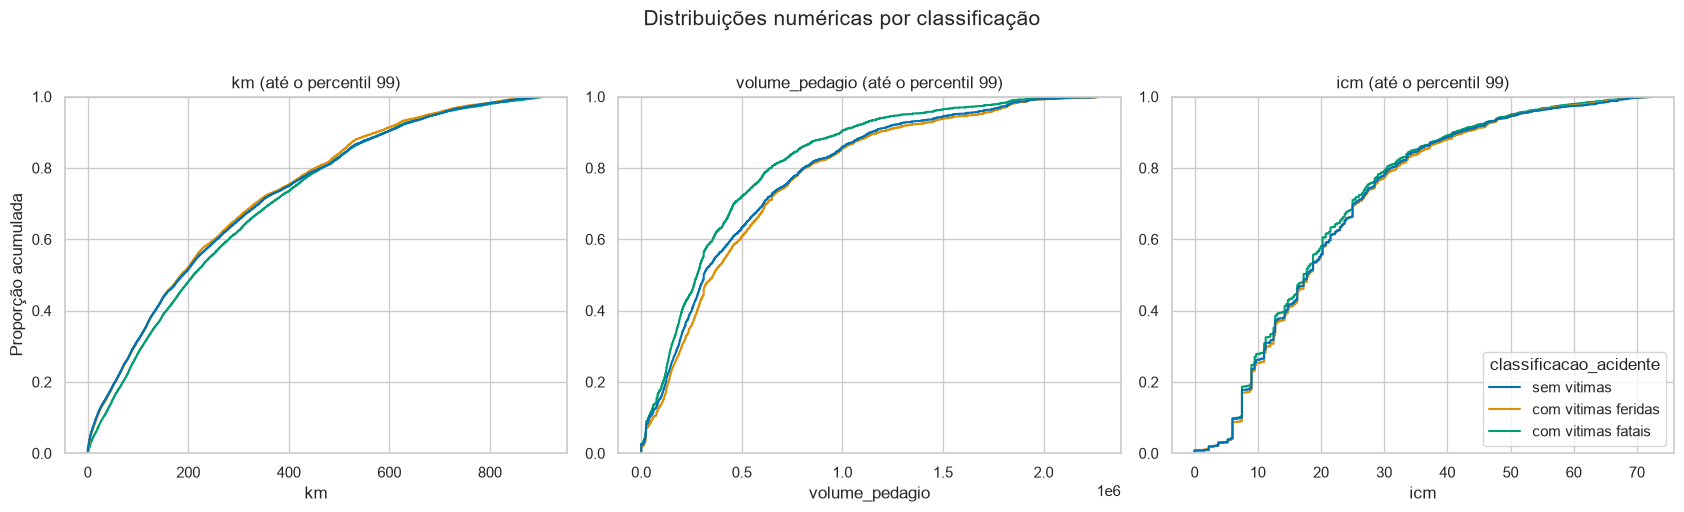

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for coluna, ax in zip(numericas, axes):
    limite = dados[coluna].quantile(0.99)
    recorte = dados.loc[dados[coluna].le(limite), [coluna, COLUNA_ALVO]]
    sns.ecdfplot(data=recorte, x=coluna, hue=COLUNA_ALVO, hue_order=ORDEM_ALVO, palette=PALETA_ALVO, ax=ax, legend=coluna == numericas[-1])
    ax.set(title=f"{coluna} (até o percentil 99)", ylabel="Proporção acumulada" if coluna == numericas[0] else "")
fig.suptitle("Distribuições numéricas por classificação", y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "eda2_distribuicoes_numericas.png", dpi=160, bbox_inches="tight")
plt.show()

### 6.1 Ausência como possível sinal

Um valor ausente não significa necessariamente erro. `volume_pedagio` pode estar ausente porque o trecho não possui praça de pedágio, por exemplo. Assim, o próprio fato de um valor estar ausente pode carregar informação sobre o local.

Comparamos a classificação entre os grupos `observado` e `ausente`. Se os percentuais mudarem, apagar essas linhas ou preencher os valores sem preservar um indicador de ausência pode esconder informação útil e introduzir viés.

In [10]:
indicadores_ausencia = []
for coluna in ["volume_pedagio", "icm"]:
    indicador = f"{coluna}_ausente"
    dados[indicador] = dados[coluna].isna().map({True: "ausente", False: "observado"})
    perfil = perfil_por_categoria(dados, indicador)
    perfil.insert(0, "variavel", coluna)
    indicadores_ausencia.append(perfil.reset_index(names="disponibilidade"))
resumo_ausencia = pd.concat(indicadores_ausencia, ignore_index=True)
display(resumo_ausencia.round(2))

classificacao_acidente,disponibilidade,variavel,n,pct_sem vitimas,pct_com vitimas feridas,pct_com vitimas fatais,fatal_ic95_inf,fatal_ic95_sup
0,ausente,volume_pedagio,77328,16.03,74.87,9.10,8.90,9.30
1,observado,volume_pedagio,110020,15.42,78.86,5.71,5.58,5.85
2,observado,icm,110381,16.17,75.33,8.51,8.34,8.67
3,ausente,icm,76967,14.97,79.92,5.11,4.96,5.27


## 7. Relações temporais

Esta seção verifica se a composição da gravidade muda com o tempo. O primeiro gráfico compara percentuais dentro de cada ano, pois o número de registros pode variar com a cobertura do período. O segundo mostra a taxa fatal por hora e inclui uma linha tracejada com a média global.

Uma taxa acima da linha global indica associação com maior proporção fatal naquele horário, não que o horário tenha causado o acidente. Outros fatores, como iluminação, velocidade, fluxo e tipo de pista, podem estar envolvidos.

classificacao_acidente,sem vitimas,com vitimas feridas,com vitimas fatais
ano,,,
2023,15.52,77.53,6.95
2024,16.10,76.76,7.14
2025,15.36,77.46,7.18
2026,15.46,77.60,6.94


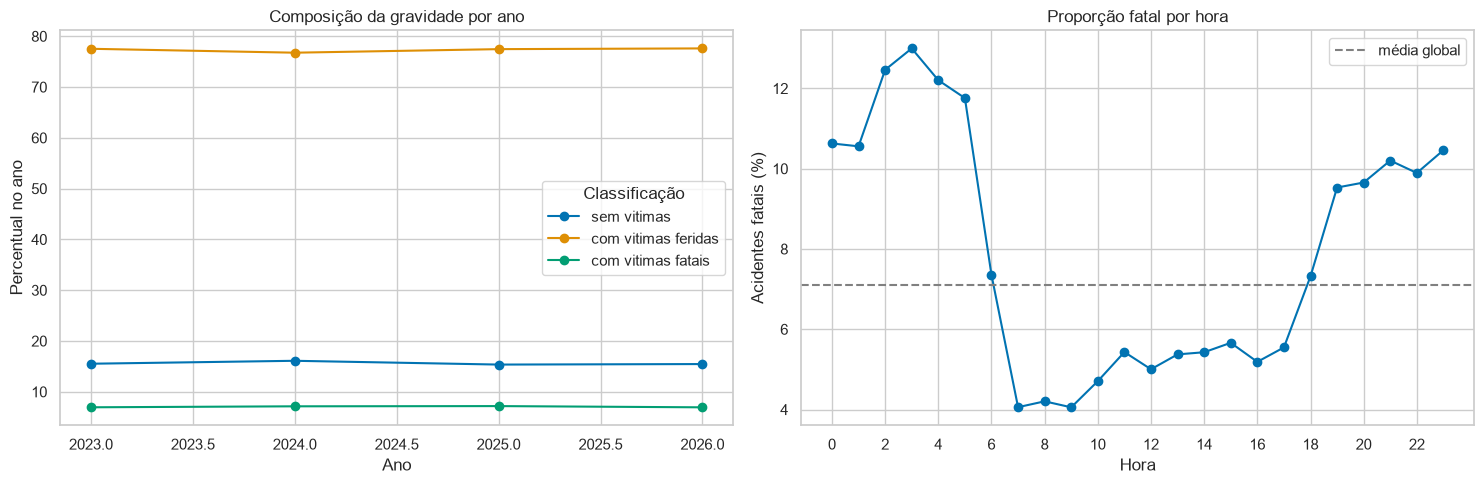

In [11]:
temporal = pd.crosstab(dados["ano"], dados[COLUNA_ALVO], normalize="index").reindex(columns=ORDEM_ALVO).mul(100)
display(temporal.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
temporal.plot(kind="line", marker="o", color=[PALETA_ALVO[c] for c in ORDEM_ALVO], ax=axes[0])
axes[0].set(title="Composição da gravidade por ano", xlabel="Ano", ylabel="Percentual no ano")
axes[0].legend(title="Classificação")
perfil_hora = perfil_por_categoria(dados, "hora")
perfil_hora.index = perfil_hora.index.astype(int)
perfil_hora = perfil_hora.sort_index()
axes[1].plot(perfil_hora.index, perfil_hora["pct_com vitimas fatais"], marker="o")
axes[1].axhline(dados["classe_fatal"].mean() * 100, color="gray", linestyle="--", label="média global")
axes[1].set(title="Proporção fatal por hora", xlabel="Hora", ylabel="Acidentes fatais (%)", xticks=range(0, 24, 2))
axes[1].legend()
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "eda2_relacoes_temporais.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Interações entre variáveis

Uma **interação** ocorre quando a relação de uma variável com o alvo depende de outra variável. Por exemplo, o padrão de `tipo_pista` pode ser diferente durante o dia e durante a noite.

Cada célula cruza duas categorias e mostra a porcentagem fatal naquela combinação. Cores mais quentes representam taxas maiores. Células com menos de 100 acidentes ficam vazias para evitar conclusões baseadas em grupos muito pequenos. Essas matrizes ajudam a levantar hipóteses que depois precisam ser confirmadas pelo modelo e pela validação.

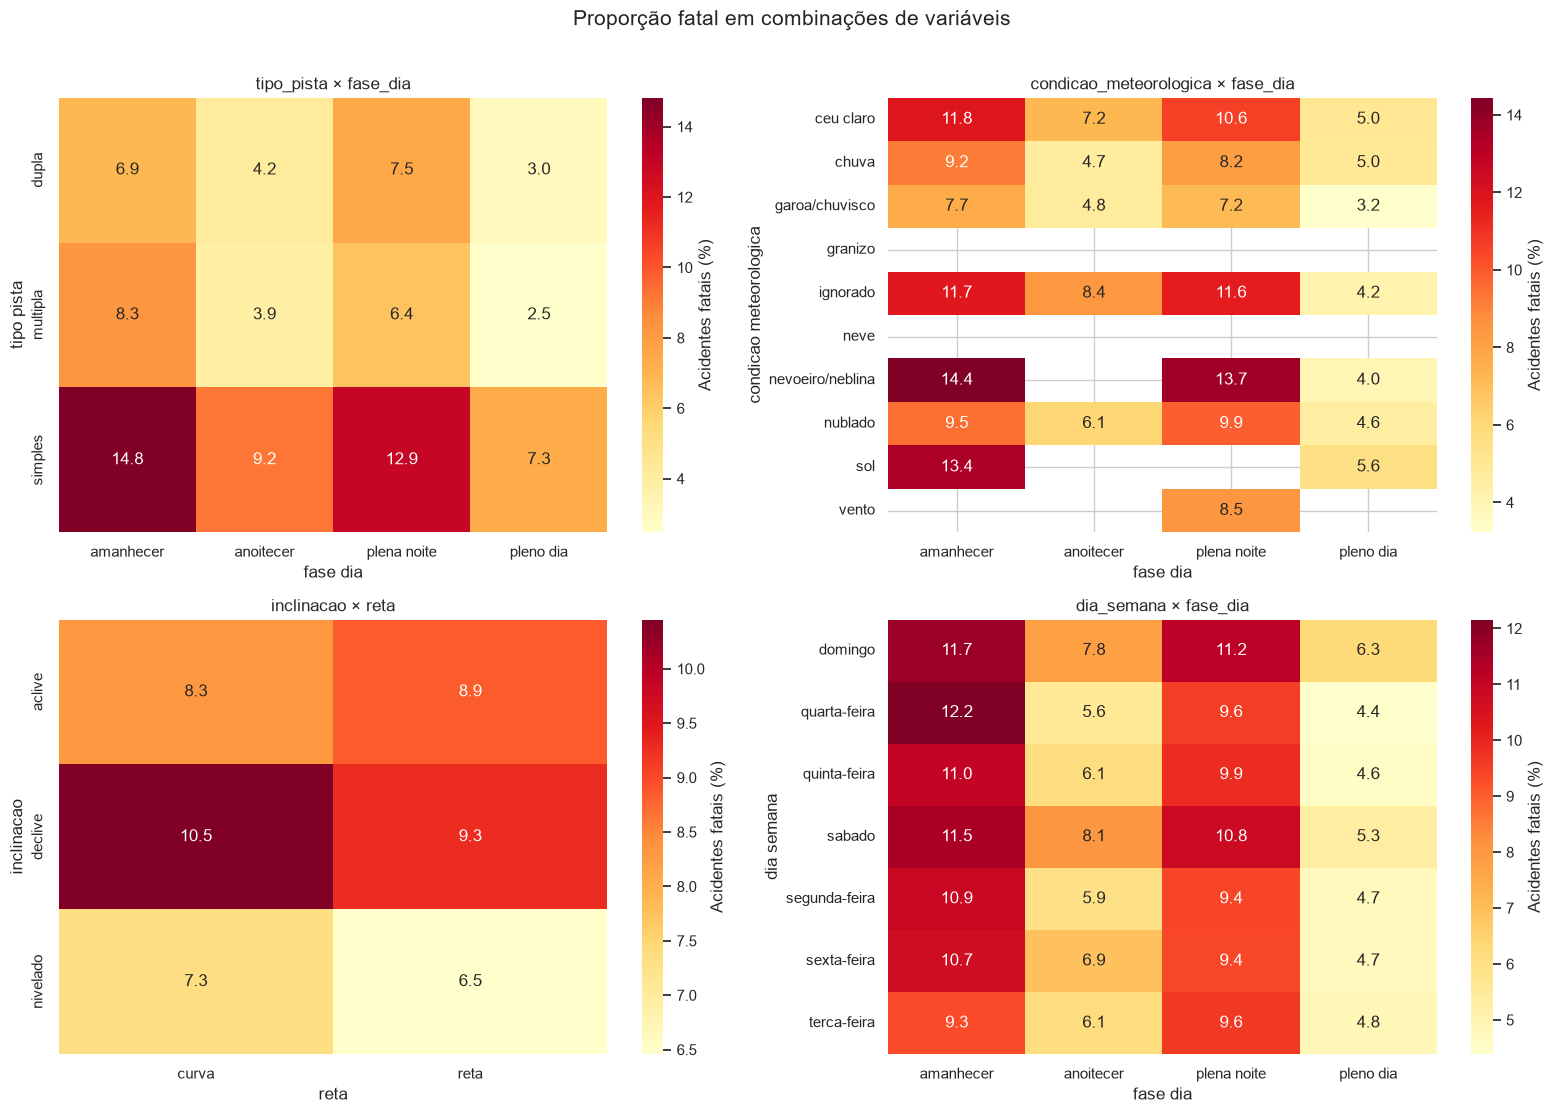

In [12]:
def matriz_taxa_fatal(df, linhas, colunas, minimo=100):
    agrupado = df.groupby([linhas, colunas], observed=True)["classe_fatal"].agg(["mean", "size"]).reset_index()
    agrupado.loc[agrupado["size"] < minimo, "mean"] = np.nan
    return agrupado.pivot(index=linhas, columns=colunas, values="mean").mul(100)

interacoes = [
    ("tipo_pista", "fase_dia"),
    ("condicao_meteorologica", "fase_dia"),
    ("inclinacao", "reta"),
    ("dia_semana", "fase_dia"),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for (linhas, colunas), ax in zip(interacoes, axes.flat):
    matriz = matriz_taxa_fatal(dados, linhas, colunas)
    sns.heatmap(matriz, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Acidentes fatais (%)"}, ax=ax)
    ax.set(title=f"{linhas} × {colunas}", xlabel=colunas.replace("_", " "), ylabel=linhas.replace("_", " "))
fig.suptitle("Proporção fatal em combinações de variáveis", y=1.01, fontsize=15)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "eda2_interacoes.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Relações entre as próprias variáveis

Também verificamos relações entre as próprias variáveis de entrada, chamadas de **preditoras**. Se duas delas forem muito associadas, podem carregar informação parecida. Nesse caso, um modelo pode dividir a importância entre ambas, e interpretar apenas uma importância individual pode ser enganoso.

A matriz categórica usa V de Cramér: a diagonal vale 1 porque toda variável é perfeitamente associada consigo mesma. Para as numéricas usamos correlação de Spearman, que varia de -1 a 1. Valores perto de 1 indicam que ambas tendem a crescer juntas; perto de -1, que uma tende a cair quando a outra cresce; e perto de 0, ausência de relação monotônica forte.

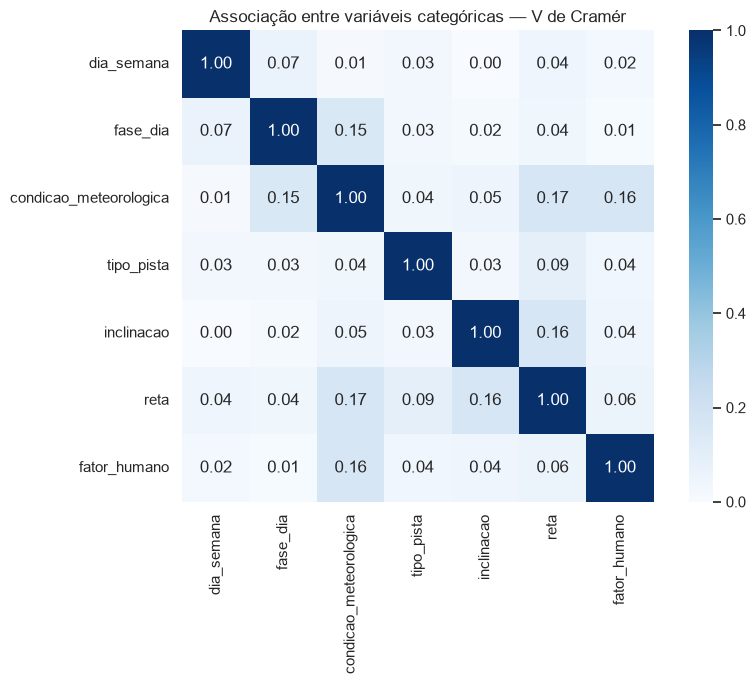

,km,volume_pedagio,icm
km,1.000,-0.140,0.037
volume_pedagio,-0.140,1.000,0.079
icm,0.037,0.079,1.000


In [13]:
def cramers_v_entre(series_a, series_b):
    tabela = pd.crosstab(series_a.astype("string").fillna("ausente"), series_b.astype("string").fillna("ausente"))
    qui2 = chi2_contingency(tabela)[0]
    n = tabela.to_numpy().sum()
    linhas, colunas = tabela.shape
    phi2_corrigido = max(0, qui2 / n - ((colunas - 1) * (linhas - 1)) / (n - 1))
    r_corrigido = linhas - ((linhas - 1) ** 2) / (n - 1)
    c_corrigido = colunas - ((colunas - 1) ** 2) / (n - 1)
    denominador = min(r_corrigido - 1, c_corrigido - 1)
    return np.sqrt(phi2_corrigido / denominador) if denominador > 0 else np.nan

preditoras_cat = ["dia_semana", "fase_dia", "condicao_meteorologica", "tipo_pista", "inclinacao", "reta", "fator_humano"]
matriz_associacao = pd.DataFrame(np.eye(len(preditoras_cat)), index=preditoras_cat, columns=preditoras_cat)
for i, coluna_a in enumerate(preditoras_cat):
    for coluna_b in preditoras_cat[i + 1:]:
        valor = cramers_v_entre(dados[coluna_a], dados[coluna_b])
        matriz_associacao.loc[coluna_a, coluna_b] = valor
        matriz_associacao.loc[coluna_b, coluna_a] = valor

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(matriz_associacao, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("Associação entre variáveis categóricas — V de Cramér")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "eda2_associacao_preditoras.png", dpi=160, bbox_inches="tight")
plt.show()

display(dados[numericas].corr(method="spearman").round(3))

## 10. Síntese orientada pelos resultados

Esta célula evita escolher resultados manualmente: ela usa os rankings calculados acima para imprimir a taxa global, a variável categórica mais associada, a variável numérica com maior efeito e a categoria com maior taxa fatal em cinco variáveis. Assim, a síntese é atualizada automaticamente quando os dados mudam.

`n` continua sendo essencial: uma taxa alta baseada em poucas observações é menos confiável. Os resultados orientam hipóteses e a modelagem, mas não demonstram causa e efeito.

In [14]:
taxa_global_fatal = dados["classe_fatal"].mean() * 100
mais_associada = ranking_categoricas.iloc[0]
maior_efeito_numerico = ranking_numericas.iloc[0]

print(f"Taxa fatal global: {taxa_global_fatal:.2f}%")
print(f"Maior associação categórica: {mais_associada['variavel']} (V={mais_associada['cramers_v']:.3f})")
print(f"Maior efeito numérico: {maior_efeito_numerico['variavel']} (epsilon²={maior_efeito_numerico['epsilon2']:.4f})")
print("Categorias com maior taxa fatal entre as que possuem ao menos 500 acidentes:")

destaques = []
for coluna in ["br", "fase_dia", "condicao_meteorologica", "tipo_pista", "dia_semana"]:
    perfil = perfil_por_categoria(dados, coluna, minimo=500)
    if not perfil.empty:
        melhor = perfil.iloc[0]
        destaques.append({"variavel": coluna, "categoria": perfil.index[0], "n": int(melhor["n"]), "fatal_pct": melhor["pct_com vitimas fatais"], "ic95_inf": melhor["fatal_ic95_inf"], "ic95_sup": melhor["fatal_ic95_sup"]})
display(pd.DataFrame(destaques).sort_values("fatal_pct", ascending=False).round(2))

Taxa fatal global: 7.11%
Maior associação categórica: br (V=0.114)
Maior efeito numérico: volume_pedagio (epsilon²=0.0038)
Categorias com maior taxa fatal entre as que possuem ao menos 500 acidentes:


,variavel,categoria,n,fatal_pct,ic95_inf,ic95_sup
0,br,423,529,18.53,15.45,22.06
2,condicao_meteorologica,nevoeiro/neblina,1535,11.66,10.15,13.36
1,fase_dia,amanhecer,8876,11.12,10.48,11.79
3,tipo_pista,simples,90142,9.79,9.60,9.98
4,dia_semana,domingo,29969,8.75,8.43,9.07


## Conclusão

Nos dados atuais, 7,11% dos registros válidos são acidentes com vítimas fatais. Entre as variáveis categóricas analisadas, `br` apresenta a maior associação com o alvo (V de Cramér de aproximadamente 0,114), seguida de perto por hora e fator humano. Isso sugere que existe algum sinal, mas nenhuma dessas variáveis separa as classes sozinha.

Entre as numéricas, `volume_pedagio` tem o maior epsilon², mas seu valor é apenas 0,0038. Em termos simples, as distribuições numéricas das três classes se sobrepõem bastante e seu efeito isolado é pequeno. A ausência de `volume_pedagio` e `icm`, porém, também se relaciona com a composição do alvo e merece ser preservada como indicador.

Alguns grupos têm taxa fatal acima da média, como amanhecer, pista simples e nevoeiro/neblina. Esses resultados não significam que essas condições causam fatalidade: elas podem estar misturadas a velocidade, localização, fluxo, iluminação e outros fatores não controlados nesta análise.

A leitura recomendada é: (1) observar o tamanho de efeito; (2) consultar `n`, percentuais e intervalos de confiança; (3) verificar interações e redundância; e (4) confirmar os sinais em dados que não participaram da exploração.